In [23]:
import argparse
import os
import numpy as np
from Bio import Phylo
import sys
import os
import copy
import math
import json
import pandas as pd
import matplotlib.pyplot as plt

# Add parent directory to sys.path
sys.path.append(os.path.abspath(".."))
import importlib
# importlib.reload(sys.modules['simulation_utils'])
from simulation_utils import *


In [24]:
fn_hosts = ['host_258952', 'host_77233', 'host_40228', 'host_246814', 'host_249034', 'host_58073', 'host_903567', 'host_372077', 'host_109485', 'host_51300', 'host_98922', 'host_302402', 'host_463808', 'host_59478', 'host_77231', 'host_58063', 'host_58069', 'host_178895', 'host_329870', 'host_40233', 'host_360967', 'host_326081', 'host_27634', 'host_1381355']

In [25]:
def read_interaction_matrix(csv_file, host_tree_file, virus_tree_file):
    """
    Read host-virus interaction matrix CSV and reorder according to tree leaves.
    Treat viruses as parasites.
    
    Returns:
        cell_state: dict with keys (virus, host) -> 0/1
        host_tree: Bio.Phylo tree object
        virus_tree: Bio.Phylo tree object
    """

    # Load trees
    host_tree = Phylo.read(host_tree_file, "newick")
    virus_tree = Phylo.read(virus_tree_file, "newick")

    # Get leaf order
    host_order = [t.name for t in host_tree.get_terminals()]
    virus_order = [t.name for t in virus_tree.get_terminals()]

    print(f"Number of hosts in tree: {len(host_order)}")
    print(f"Number of viruses in tree: {len(virus_order)}")

    # Load interaction matrix CSV
    df = pd.read_csv(csv_file, index_col=0)  # assuming rows=viruses, columns=hosts
    # Ensure names match the expected tree leaf names
    df = df.loc[df.index.intersection(virus_order), df.columns.intersection(host_order)]

    # Reorder according to tree leaves
    df = df.reindex(index=virus_order, columns=host_order, fill_value=0)

    # Build cell_state dictionary
    cell_state = {}
    seed = 42
    np.random.seed(seed)
    for virus in virus_order:
        for host in host_order:
            cell_state[(virus, host)] = int(df.at[virus, host])
            # if host in fn_hosts:
                # if np.random.rand() < 0.03:
                #     cell_state[(virus, host)] = 13

    return cell_state, host_tree, virus_tree







outdir = "experiments"
association_csv = "interaction_matrix_tree_leaves_beta_only.csv"
host_tree = "virion_bat_cov_output/trees/hosts_tree.newick"
virus_tree = "virion_bat_cov_output/trees/viruses_tree_beta_only.newick"




os.makedirs(outdir, exist_ok=True)

# Read associations + trees
cell_state, base_host_tree, base_par_tree = read_interaction_matrix(
    association_csv, host_tree, virus_tree
)

base_host_tree = rescale_tree(base_host_tree)
base_par_tree = rescale_tree(base_par_tree)

# print (base_host_tree)
# print (base_par_tree)

host_leaves = [t.name for t in base_host_tree.get_terminals()]
par_leaves = [t.name for t in base_par_tree.get_terminals()]

out = {
    "host_trees": [copy.deepcopy(base_host_tree) for _ in range(len(par_leaves))],
    "par_trees": [copy.deepcopy(base_par_tree) for _ in range(len(host_leaves))],
    "cell_state": cell_state,
    "host_leaves": host_leaves,
    "par_leaves": par_leaves
}

# Build the matrix
mat, parasites, hosts = get_interaction_matrix(out)

# Save the matrix visualization
# plot_matrix(mat, parasites, hosts, filename=os.path.join(outdir, "original_matrix_beta_only.png"))







Number of hosts in tree: 229
Number of viruses in tree: 22


In [26]:
# Load taxonomy and benchmark data
host_tax = pd.read_csv("taxonomy_host.csv", dtype=str).fillna("")
virus_tax = pd.read_csv("taxonomy_virus.csv", dtype=str).fillna("")
betacov = pd.read_csv("BinaryWebsite.csv", dtype=str).fillna("")
ensemble_df = pd.read_csv("WeightedEnsemble2020.csv", dtype=str)
ensemble_df["Sp"] = ensemble_df["Sp"].str.strip().str.lower()
ensemble_df["Ensemble.2"] = ensemble_df["Ensemble.2"].astype(float)
hybrid_modified_df = pd.read_csv("stock.csv", dtype=str)
hybrid_modified_df["Sp"] = hybrid_modified_df["Sp"].str.strip().str.lower()
hybrid_modified_df["R.Stock1_prop"] = hybrid_modified_df["R.Stock1_prop"].astype(float)
hybrid_modified_df["P.Stock1"] = hybrid_modified_df["P.Stock1"].astype(float)

trait1_df=pd.read_csv("Trait1_model.csv", dtype=str)
trait1_df["Sp"] = trait1_df["Sp"].str.strip().str.lower()
trait1_df["R.Gut1_prop"] = trait1_df["R.Gut1_prop"].astype(float)

trait2_df=pd.read_csv("../Fresnel/Fresnel/trait2_model.csv", dtype=str)
trait2_df["Sp"] = trait2_df["Sp"].str.strip().str.lower()
trait2_df["R.Car3_prop"] = trait2_df["R.Car3_prop"].astype(float)

trait3_df=pd.read_csv("../Fresnel/Fresnel/Trait3_model.csv", dtype=str)
trait3_df["Sp"] = trait3_df["Sp"].str.strip().str.lower()
trait3_df["R.Alb_prop"] = trait3_df["R.Alb_prop"].astype(float)

network1_df=pd.read_csv("../Fresnel/Fresnel/Network1_model.csv", dtype=str)
network1_df["Sp"] = network1_df["Sp"].str.strip().str.lower()
network1_df["R.Po2_prop"] = network1_df["R.Po2_prop"].astype(float)

network3_df=pd.read_csv("../Fresnel/Fresnel/Network3_model.csv", dtype=str)
network3_df["Sp"] = network3_df["Sp"].str.strip().str.lower()
network3_df["R.Dal1_prop"] = network3_df["R.Dal1_prop"].astype(float)

network4_df=pd.read_csv("Network4_model.csv", dtype=str)
network4_df["Sp"] = network4_df["Sp"].str.strip().str.lower()
network4_df["R.Far1_prop"] = network4_df["R.Far1_prop"].astype(float).fillna(0.01)

network2_df=pd.read_csv("Network2_model.csv", dtype=str)
network2_df["Sp"] = network2_df["Sp"].str.strip().str.lower()
network2_df["R.Po3_prop"] = network2_df["R.Po3_prop"].astype(float).fillna(0.01)
# print (network2_df

# Read the CSV
scores_df = pd.read_csv("scores_tskrr_both.csv",dtype=str)

# Detect the host name column (first column, may be unnamed)
host_col = scores_df.columns[0]

# Take only host names and Betacoronavirus column
if "Betacoronavirus" not in scores_df.columns:
    raise ValueError("Column 'Betacoronavirus' not found in scores_tskrr_both.csv")

hybrid_df = scores_df[[host_col, "Betacoronavirus"]].copy()

# Rename columns for clarity
hybrid_df.columns = ["", "Betacoronavirus"]

# Clean host names: strip spaces, replace underscores with spaces, make lowercase
hybrid_df[""] = (
    hybrid_df[""]
    .astype(str)
    .str.strip()
    .str.replace("_", " ", regex=False)
    .str.lower()
)

# Convert Betacoronavirus scores to float
hybrid_df["Betacoronavirus"] = hybrid_df["Betacoronavirus"].astype(float)
# print (hybrid_df.head())

# Normalize text columns (case-insensitive matching)
for df in [host_tax, virus_tax, betacov]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip().str.lower()


# Deduplicate taxonomy files by ID
host_tax = host_tax.drop_duplicates("HostTaxID")
virus_tax = virus_tax.drop_duplicates("VirusTaxID")

# Build lookup dicts
host_lookup = dict(zip(host_tax["HostTaxID"], host_tax["Host"]))
virus_lookup = dict(zip(virus_tax["VirusTaxID"], virus_tax["VirusGenus"]))
virus_lookup_names = dict(zip(virus_tax["VirusTaxID"], virus_tax["Virus"]))
betacov_hosts_set = set(betacov["Sp"])
virion_betacov_hosts_id = [h for h in hosts if host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set]
betacov_true_hosts = set(betacov.loc[betacov["Ensemble"] == "true +", "Sp"])
betacov_negative_hosts = set(betacov.loc[betacov["Ensemble"] == "false -", "Sp"])
betacov_suspected_hosts = set(betacov.loc[betacov["Ensemble"] == "suspected", "Sp"])
betacov_unlikely_hosts = set(betacov.loc[betacov["Ensemble"] == "unlikely", "Sp"])



# --- Define which columns map to which models ---
model_columns = {
    "ensemble": "Ensemble",
    "model1": "Trait.1",
    "model2": "Trait.2",
    "model3": "Trait.3",
    "model4": "Hybrid",
    "model5": "Network.1",
    "model6": "Network.2",
    "model7": "Network.3",
    "model8": "Network.4",
}

# --- Extract truth sets for each model automatically ---
truth_sets = {}
for model_name, col in model_columns.items():
    truth_sets[model_name] = {
        "true": set(betacov.loc[betacov[col] == "true +", "Sp"]),
        "suspected": set(betacov.loc[betacov[col] == "suspected", "Sp"]),
        "negative": set(betacov.loc[betacov[col] == "false -", "Sp"]) | set(betacov.loc[betacov[col] == "", "Sp"]),
        "unlikely": set(betacov.loc[betacov[col] == "unlikely", "Sp"]),
    }


categories = ["true", "suspected", "negative", "unlikely"]

virion_sets = {}
for model_name, sets in truth_sets.items():
    virion_sets[model_name] = {}

    for category in categories:
        sp_set = sets[category]
        virion_sets[model_name][category] = [
            h for h in hosts if host_lookup.get(h.split("_", 1)[1], "") in sp_set
        ]

    virion_sets[model_name]["precision"] = len(virion_sets[model_name]["true"])/(len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["suspected"])) if (len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["suspected"]))>0 else 0
    virion_sets[model_name]["recall"] = len(virion_sets[model_name]["true"])/(len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["negative"])) if (len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["negative"]))>0 else 0

    # print (f"Number of swaps performed in {model_name}: {c}")
# --- Map VIRION hosts into each model’s categories ---



# Example: check counts becareful about precision/recall calculation
for model_name in virion_sets:
    print(f"\n{model_name.upper()} counts:")
    for category, hs in virion_sets[model_name].items():
        if category in ["precision", "recall"]:
            continue
        print(f"  {category}: {len(hs)}")






print("Betacov hosts evaluation:")
print(f"  True +  : {len(betacov_true_hosts)} ")
print(f"  False - : {len(betacov_negative_hosts)} ")
print(f"  Suspected: {len(betacov_suspected_hosts)}")
print(f"  Unlikely : {len(betacov_unlikely_hosts)} ")


# print virion model precisions and recalls
for model_name, sets in virion_sets.items():
    precision = sets["precision"]
    recall = sets["recall"]
    print(f"{model_name.upper()} - Precision: {precision:.3f}, Recall: {recall:.3f}")




ENSEMBLE counts:
  true: 58
  suspected: 76
  negative: 3
  unlikely: 48

MODEL1 counts:
  true: 57
  suspected: 100
  negative: 4
  unlikely: 24

MODEL2 counts:
  true: 57
  suspected: 79
  negative: 4
  unlikely: 45

MODEL3 counts:
  true: 56
  suspected: 112
  negative: 10
  unlikely: 7

MODEL4 counts:
  true: 57
  suspected: 30
  negative: 5
  unlikely: 93

MODEL5 counts:
  true: 43
  suspected: 68
  negative: 74
  unlikely: 0

MODEL6 counts:
  true: 61
  suspected: 7
  negative: 55
  unlikely: 62

MODEL7 counts:
  true: 55
  suspected: 66
  negative: 61
  unlikely: 3

MODEL8 counts:
  true: 57
  suspected: 65
  negative: 59
  unlikely: 4
Betacov hosts evaluation:
  True +  : 72 
  False - : 7 
  Suspected: 371
  Unlikely : 666 
ENSEMBLE - Precision: 0.433, Recall: 0.951
MODEL1 - Precision: 0.363, Recall: 0.934
MODEL2 - Precision: 0.419, Recall: 0.934
MODEL3 - Precision: 0.333, Recall: 0.848
MODEL4 - Precision: 0.655, Recall: 0.919
MODEL5 - Precision: 0.387, Recall: 0.368
MODEL6 -

In [27]:
MODEL="ensemble"  # Change this to select different models

In [28]:
def current_positive_hosts(cell_state, betacov, virion_sets):
    current = set()
    
    for (virus_id, host_id), val in cell_state.items():
        v = virus_id.split("_", 1)[1]
        h = host_id.split("_", 1)[1]
        host_name = host_lookup.get(h, "")
        virus_genus = virus_lookup.get(v, "")

        if val == 1 and virus_genus == "betacoronavirus":
            if host_name in betacov["Sp"].values:
                current.add(host_id)

    # ground sets
    gt_pos = set(virion_sets["ensemble"]["true"]) | set(virion_sets["ensemble"]["negative"])
    gt_neg = set(virion_sets["ensemble"]["suspected"]) | set(virion_sets["ensemble"]["unlikely"])

    
    # classification
    tp = list(current & gt_pos)
    fp = list(current & gt_neg)
    fn = list(gt_pos - current)
    tn = list(gt_neg - current)

    # print(f"Predicted betacoronavirus hosts: {len(current)}")
    # print(f"TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")

    return tp, tn, fp, fn
tp, tn, fp, fn = current_positive_hosts(cell_state, betacov, virion_sets)
fn_hosts=fn.copy()
tn_hosts=tn.copy()
virion_negative_hosts=(fn+tn).copy()
print ("Virion Negative Hosts:", len(virion_negative_hosts))

print ("Virion TP:", len(tp), "TN:", len(tn), "FP:", len(fp), "FN:", len(fn))

Virion Negative Hosts: 116
Virion TP: 37 TN: 92 FP: 32 FN: 24


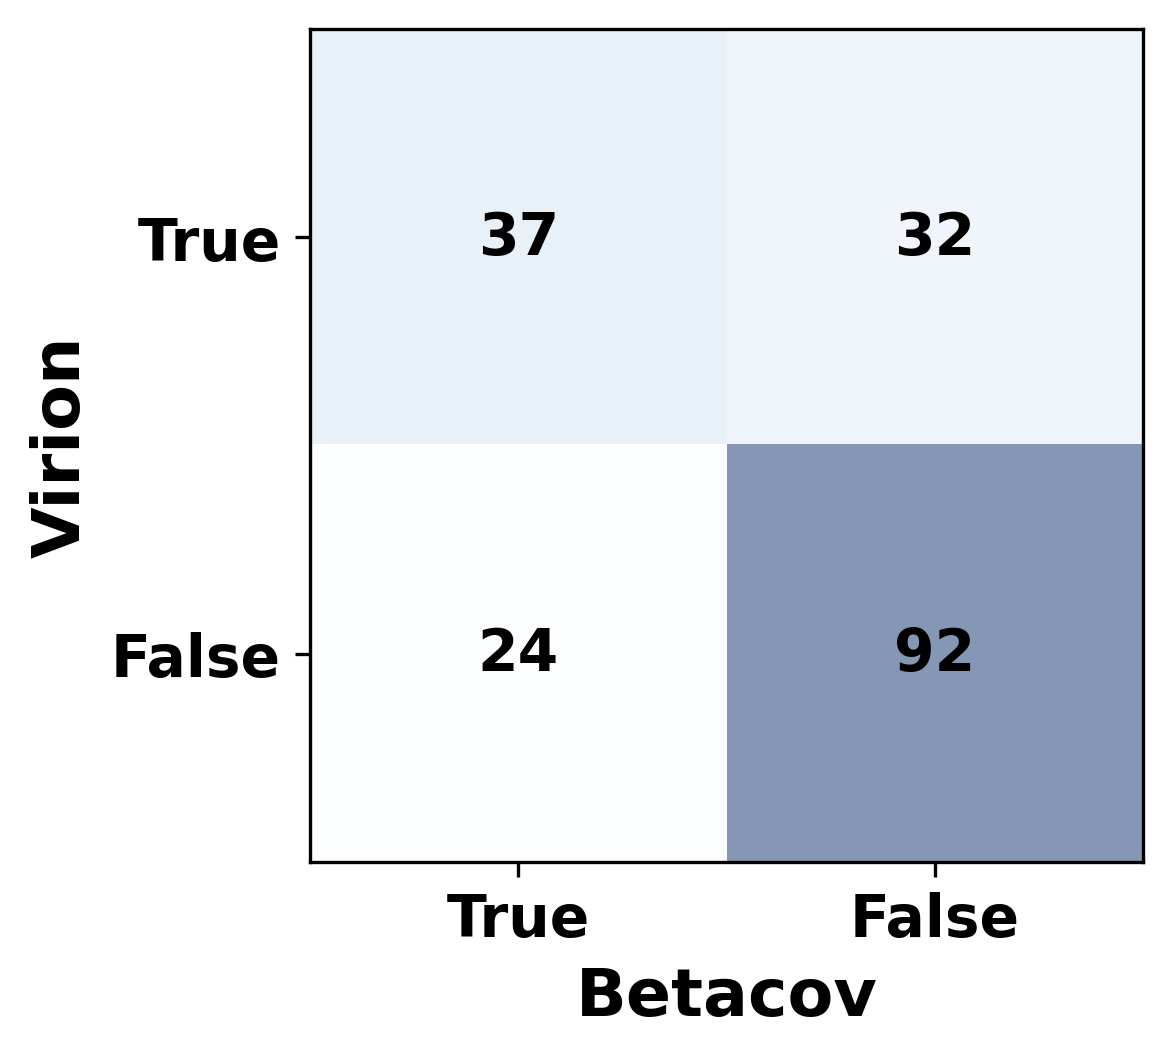

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Example counts (replace with your actual values)
TP = len(tp)
TN = len(tn)
FP = len(fp)
FN = len(fn)

# --- Confusion matrix (Virion vs Betacov) ---
# Rows = Virion (Actual)
# Columns = Betacov (Predicted)
conf_matrix = np.array([[TP, FP],   # Virion True/False (actual)
                        [FN, TN]])  # Virion False (actual)

# --- Plot ---
fig, ax = plt.subplots(figsize=(4,4), dpi=300)

im = ax.imshow(conf_matrix, cmap="Blues", alpha=0.5)

# Annotate each cell with count
for i in range(2):
    for j in range(2):
        ax.text(j, i, conf_matrix[i, j],
                ha='center', va='center',
                color='black', fontsize=14, fontweight='bold')

# --- Axis labels ---
ax.set_xticks([0,1])
ax.set_xticklabels(['True', 'False'], fontsize=14, fontweight='bold')
ax.set_yticks([0,1])
ax.set_yticklabels(['True', 'False'], fontsize=14, fontweight='bold')

# --- Axis titles ---
ax.set_xlabel('Betacov', fontsize=16, fontweight='bold')
ax.set_ylabel('Virion', fontsize=16, fontweight='bold')

# --- Title ---
# ax.set_title('Confusion Matrix: Virion vs Betacov', fontsize=16, pad=15)

# --- Final style ---
plt.tight_layout()
plt.savefig('confusion_matrix_virion_betacov.svg', transparent=True, bbox_inches='tight')
plt.show()


In [30]:
import json
import os

# Convert virion_sets host IDs → host names
virion_sets_named = {}

for model_name, sets in virion_sets.items():
    virion_sets_named[model_name] = {}
    for key, value in sets.items():
        if key in ["precision", "recall"]:
            virion_sets_named[model_name][key] = value
        else:
            # Replace IDs with host names
            names = []
            for h in value:
                taxid = h.split("_", 1)[1] if "_" in h else h
                host_name = host_lookup.get(taxid, h)
                names.append(host_name)
            virion_sets_named[model_name][key] = names

# Save to JSON
with open("virion_sets_named.json", "w", encoding="utf-8") as f:
    json.dump(virion_sets_named, f, indent=2, ensure_ascii=False)

print("✅ Saved virion_sets_named.json with host names instead of IDs.")


✅ Saved virion_sets_named.json with host names instead of IDs.


In [31]:
out_original = out.copy()  # Keep original for each run

In [32]:


def matrix_builder(out, r01_h, r10_h, r01_p, r10_p):
    # Build weight matrices for each parasite’s host tree
    flip_cost_map = dict(zip(ensemble_df["Sp"], ensemble_df["Ensemble.2"]))
    # flip_cost_map = dict(zip(hybrid_modified_df["Sp"], hybrid_modified_df["R.Stock1_prop"]))
    # flip_cost_map = dict(zip(network1_df["Sp"], network1_df["R.Po2_prop"]))
    # flip_cost_map = dict(zip(trait1_df["Sp"], trait1_df["R.Gut1_prop"]))
    # flip_cost_map = dict(zip(trait2_df["Sp"], trait2_df["R.Car3_prop"]))
    # flip_cost_map = dict(zip(trait3_df["Sp"], trait3_df["R.Alb_prop"]))
    # flip_cost_map = dict(zip(network4_df["Sp"], network4_df["R.Far1_prop"]))
    # flip_cost_map = dict(zip(network2_df["Sp"], network2_df["R.Po3_prop"]))
    # flip_cost_map = dict(zip(network3_df["Sp"], network3_df["R.Dal1_prop"]))
    #  find max and min of flip_cost_map values
    # max_cost = max(flip_cost_map.values())
    # min_cost = min(flip_cost_map.values())
    # max_log_cost = math.log(max_cost)
    # min_log_cost = math.log(min_cost)
    host_W_matrices = []
    for t in out["host_trees"]:
        W, nodes = build_weight_matrix(t, r01_h, r10_h, scale=100.0)
        # scale W
        W = W*100
        host_W_matrices.append((W, nodes))

    # Build weight matrices for each host’s parasite tree
    par_W_matrices = []
    for t in out["par_trees"]:
        W, nodes = build_weight_matrix(t, r01_p, r10_p, scale=100.0)
        # scale W
        W = W*1
        par_W_matrices.append((W, nodes))
    # Flip cost matrix
    flip_cost_matrix = build_flip_cost_matrix(len(out["par_leaves"]), len(out["host_leaves"]), cost=1.0)
    c=0
    for host_idx, host in enumerate(out["host_leaves"]):
        host_name = host_lookup.get(host.split("_", 1)[1], "")

        if host_name in flip_cost_map:
                flip_cost_matrix[:, host_idx] = 1.0*flip_cost_map[host_name]

    print(c)
    return host_W_matrices, par_W_matrices, flip_cost_matrix
out_corrupt = out_original.copy()
hidden_cells = []


r01_p, r10_p, r01_h, r10_h = 0.7,0.3,0.5,0.5
host_W_matrices, par_W_matrices, flip_cost_matrix = matrix_builder(out_corrupt, r01_h, r10_h, r01_p, r10_p)

0


In [33]:
def binary_search_lambda(target_flips, 
                         out_corrupt, host_W_matrices, par_W_matrices, flip_cost_matrix,
                         tol=1, max_iter=30, lambda_min=0.0, lambda_max=1.0):
    """
    Find lambda that yields approximately target_flips using binary search.
    """
    low, high = lambda_min, lambda_max
    best_lambda = None
    best_diff = float('inf')
    history = []

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        cut_result = solve_network_cut(out_corrupt, 
                                       host_W_matrices=host_W_matrices, 
                                       par_W_matrices=par_W_matrices,
                                       flip_cost_matrix=flip_cost_matrix,
                                       lambda_param=mid)
        flips = cut_result["flips"]
        current = set()
        for virus_id, host_id, old, new in flips:   # flips = cut_result["flips"]
            v = virus_id.split("_", 1)[1]
            h = host_id.split("_", 1)[1]

            host_name = host_lookup.get(h, "")
            virus_genus = virus_lookup.get(v, "")

            if not host_name:
                status = "host_unknown"
            elif not virus_genus:
                # print (f"Warning: For Virus ID {v} Genus not found in taxonomy.")
                status = "virus_unknown"
            else:
                if virus_genus == "betacoronavirus":
                    if host_name in betacov["Sp"].values:
                        current.add(host_id)
                    
        
            # ground sets
        gt_pos = set(virion_sets[MODEL]["true"]) | set(virion_sets[MODEL]["negative"])
        gt_neg = set(virion_sets[MODEL]["suspected"]) | set(virion_sets[MODEL]["unlikely"])

        # classification
        tp = list(current & gt_pos)
        fp = list(current & gt_neg)
        fn = list(gt_pos - current)
        tn = list(gt_neg - current)
        n_flips = len(tp) + len(fp)
        diff = abs(n_flips - target_flips)
        history.append((mid, n_flips))

        if diff < best_diff:
            best_diff = diff
            best_lambda = mid

        print(f"λ={mid:.4f} → flips={n_flips} (target={target_flips})")

        # adjust bounds
        if n_flips > target_flips:
            # too many flips → increase lambda (more regularization, fewer flips)
            high = mid
        elif n_flips < target_flips:
            # too few flips → decrease lambda
            low = mid
        else:
            # exact match
            break

        if diff <= tol:
            break

    print(f"✅ Best λ ≈ {best_lambda:.4f} → {best_diff} flips away from target")
    return best_lambda, history

best_lambda,_=binary_search_lambda(len(virion_sets[MODEL]["true"])+len(virion_sets[MODEL]["suspected"]), out_corrupt, host_W_matrices, par_W_matrices, flip_cost_matrix)
# best_lambda,_=binary_search_lambda(100, out_corrupt, host_W_matrices, par_W_matrices, flip_cost_matrix)

λ=0.5000 → flips=185 (target=134)
λ=0.2500 → flips=175 (target=134)
λ=0.1250 → flips=125 (target=134)
λ=0.1875 → flips=175 (target=134)
λ=0.1562 → flips=158 (target=134)
λ=0.1406 → flips=176 (target=134)
λ=0.1328 → flips=157 (target=134)
λ=0.1289 → flips=135 (target=134)
✅ Best λ ≈ 0.1289 → 1 flips away from target


In [34]:
# ---------------------------
# Step 2: Run network cut recovery on corrupted input
# ---------------------------

# print ("before flip")
# print (current_positive_hosts(out_original["cell_state"], betacov, virion_sets))
lambda_param=0.147
# lambda_param=best_lambda
cut_result = solve_network_cut(out_corrupt, 
                               host_W_matrices=host_W_matrices, 
                               par_W_matrices=par_W_matrices,
                               flip_cost_matrix=flip_cost_matrix,
                               lambda_param=lambda_param)





new_mat = cut_result["new_matrix"]
new_cell_state = cut_result["new_cell_state"]
flips = cut_result["flips"]
highlight_flipped = {"flipped": [(p, h) for p, h, old, new in flips]}
print(f"Number of flips performed: {len(flips)}")

# fn_current = set()
for p, h, old, new in flips:
    print(f"Cell ({p},{h}): {old} -> {new}")
#     # count unique hosts that were flipped from 0 to 1 and h in fn_hosts
#     if old == 0 and new == 1 and h in fn_hosts:
#         fn_current.add(h)
# print(f"Number of FN hosts recovered: {len(fn_current)}")











current = set()
fn_to_pos = set()
for virus_id, host_id, old, new in flips:   # flips = cut_result["flips"]
    v = virus_id.split("_", 1)[1]
    h = host_id.split("_", 1)[1]

    host_name = host_lookup.get(h, "")
    virus_genus = virus_lookup.get(v, "")

    if not host_name:
        status = "host_unknown"
    elif not virus_genus:
        # print (f"Warning: For Virus ID {v} Genus not found in taxonomy.")
        status = "virus_unknown"
    else:
        if virus_genus == "betacoronavirus":
            if host_name in betacov["Sp"].values:
                current.add(host_id)
            if host_id in fn_hosts and new == 1:
                fn_to_pos.add(host_id)
print (f"FN hosts recovered: {fn_to_pos}")
    # ground sets
gt_pos = set(virion_sets[MODEL]["true"]) | set(virion_sets[MODEL]["negative"])
gt_neg = set(virion_sets[MODEL]["suspected"]) | set(virion_sets[MODEL]["unlikely"])

# classification
tp = list(current & gt_pos)
fp = list(current & gt_neg)
fn = list(gt_pos - current)
tn = list(gt_neg - current)

print(f"Predicted betacoronavirus hosts after flip: {len(current)}")
print(f"TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")




tp, tn, fp, fn = current_positive_hosts(new_cell_state, betacov, virion_sets)
print ("After flip Virion TP:", len(tp), "TN:", len(tn), "FP:", len(fp), "FN:", len(fn))

cost_matrix = np.array([[0, 1],
                        [1, 0]])  # symmetric 0↔1 cost

host_root_states = {}
for h in hosts:
    root_state = find_state_of_root_using_sankoff(out["par_trees"][0], {p: cut_result["new_cell_state"][(p,h)] for p in parasites}, cost_matrix)
    host_root_states[h] = root_state

# Extract predicted positive hosts
current = {h for h, s in host_root_states.items() if s == 1 and host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set}

# find true positives, false positives, etc.
gt_pos = set(virion_sets[MODEL]["true"]) | set(virion_sets[MODEL]["negative"])
gt_neg = set(virion_sets[MODEL]["suspected"]) | set(virion_sets[MODEL]["unlikely"])
tp = list(current & gt_pos)
fp = list(current & gt_neg)
fn = list(gt_pos - current)
tn = list(gt_neg - current)
print(f"Predicted betacoronavirus hosts in root level after flip: {len(current)}")
print(f"TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")


# --- Predicted positives: hosts whose root state = 1 and appear in betacov dataset ---
host_root_states = cut_result["root_states"]
current = {h for h, s in host_root_states.items() if s == 1 and host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set}


# --- Compute confusion matrix sets ---
tp = current & gt_pos
fp = current & gt_neg
fn = gt_pos - current
tn = gt_neg - current

# --- Metrics ---
precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) else 0
recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) else 0

print (f"At root level after flip using algo: TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")

# ---------------------------
# Step 3: Save recovered matrix with algorithm flips
# ---------------------------
# plot_matrix(new_mat, parasites, hosts,
#             filename=os.path.join(outdir, "flipped_matrix_beta_only.png"),
#             highlight=highlight_flipped)






# inside main(), after you have flips and hidden_cells
# metrics = compute_metrics(hidden_cells, flips)
# print("Metrics:", metrics)






Number of flips performed: 568
Cell (virus_1335626,host_105295): 0 -> 1
Cell (virus_1335626,host_258946): 0 -> 1
Cell (virus_1335626,host_187011): 0 -> 1
Cell (virus_1335626,host_51300): 0 -> 1
Cell (virus_1335626,host_246814): 0 -> 1
Cell (virus_1335626,host_59473): 0 -> 1
Cell (virus_1335626,host_109485): 0 -> 1
Cell (virus_1335626,host_59474): 0 -> 1
Cell (virus_1335626,host_999321): 0 -> 1
Cell (virus_1335626,host_867834): 0 -> 1
Cell (virus_1335626,host_138978): 0 -> 1
Cell (virus_1335626,host_143942): 0 -> 1
Cell (virus_1335626,host_258889): 0 -> 1
Cell (virus_1335626,host_2491053): 0 -> 1
Cell (virus_1335626,host_110938): 0 -> 1
Cell (virus_1335626,host_258944): 0 -> 1
Cell (virus_1335626,host_258959): 0 -> 1
Cell (virus_1335626,host_526822): 0 -> 1
Cell (virus_1335626,host_59485): 0 -> 1
Cell (virus_1805463,host_258946): 0 -> 1
Cell (virus_1805463,host_187011): 0 -> 1
Cell (virus_1805463,host_51300): 0 -> 1
Cell (virus_1805463,host_246814): 0 -> 1
Cell (virus_1805463,host_59473

In [38]:
import pandas as pd
import numpy as np
import os

# assume you already have:
# new_mat (numpy array)   → shape: (n_parasites, n_hosts)
# parasites (list of virus IDs)
# hosts (list of all host IDs)
# fn_hosts (set or list of host IDs to keep)
# outdir (output folder path)

# 1️⃣ keep only columns whose host is in fn_hosts, in same order
fn_hosts_ordered = [h for h in hosts if h in fn_hosts]

# 2️⃣ get column indices for these hosts
fn_indices = [hosts.index(h) for h in fn_hosts_ordered]

# 3️⃣ subset the matrix
sub_mat = new_mat[:, fn_indices]


#  if any column in sub_mat has all ones, randomly remove 50% to 70% of ones

for col_idx in range(sub_mat.shape[1]):
    col = sub_mat[:, col_idx]

# 4️⃣ make a labeled DataFrame
df = pd.DataFrame(sub_mat, index=parasites, columns=fn_hosts_ordered)

# 5️⃣ save to CSV
out_path = os.path.join(outdir, "flipped_matrix_fn_hosts.csv")
df.to_csv(out_path)

print(f"Saved filtered matrix ({len(parasites)}×{len(fn_hosts_ordered)}) to {out_path}")


# plot_matrix(sub_mat, parasites, fn_hosts_ordered,
#             filename=os.path.join(outdir, "flipped_matrix_fn_hosts_beta_only.png"))


Saved filtered matrix (22×24) to experiments/flipped_matrix_fn_hosts.csv


In [36]:
import pandas as pd

# --- Read your matrix ---
df = pd.read_csv("experiments/flipped_matrix_fn_hosts.csv", index_col=0)

# --- Define your desired order ---
virus_order = [
    "virus_1805463", "virus_3061635", "virus_3068888", "virus_2833184", "virus_864596",
    "virus_3068538", "virus_694009", "virus_3433764", "virus_989337",
    "virus_2833022", "virus_2913444", "virus_3418614", "virus_3418613", "virus_2913443",
    "virus_1335626", "virus_2832974", "virus_3433775", "virus_1928434", "virus_3433757",
    "virus_3418615", "virus_3433776"
]

host_order = [
    "host_372077", "host_903567", "host_77231", "host_58073", "host_58063", "host_77233",
    "host_326081", "host_302402", "host_463808", "host_58069", "host_178895", "host_59478",
    "host_329870", "host_1381355", "host_27634", "host_40228", "host_40233", "host_51300",
    "host_246814", "host_109485", "host_360967", "host_98922", "host_249034", "host_258952"
]

# --- Reorder safely (only keep names that exist in df) ---
df = df.loc[[v for v in virus_order if v in df.index],
            [h for h in host_order if h in df.columns]]

# --- Save reordered matrix ---
df.to_csv("flipped_matrix_reordered.csv")

print("✅ Reordered matrix saved as flipped_matrix_reordered.csv")
print(f"Matrix shape: {df.shape}")

✅ Reordered matrix saved as flipped_matrix_reordered.csv
Matrix shape: (21, 24)


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_matrix(mat, filename="matrix.png", highlight=None):
    """
    Plot binary virus–host matrix (no labels or ticks).
    
    highlight: dict with keys as category name and values as 
               list of (row_idx, col_idx) coordinates.
               Example:
               {
                   "corrupted": [(0,1), (3,2)],
                   "flipped": [(4,5)]
               }
    """
    fig, ax = plt.subplots(figsize=(mat.shape[1]*0.4, mat.shape[0]*0.4))

    # Copy matrix
    color_mat = np.copy(mat).astype(float)

    # Reserve codes for highlights
    code_map = {"corrupted": 2, "flipped": 3}
    if highlight is not None:
        for category, cells in highlight.items():
            if category not in code_map:
                continue
            for i, j in cells:
                color_mat[i, j] = code_map[category]

    # Colormap
    cmap = mcolors.ListedColormap(['lightgray', 'darkgreen', 'orange', 'red'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    ax.imshow(color_mat, cmap=cmap, norm=norm)

    # Remove ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])

    # Optional: add thin gridlines
    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close(fig)
    print(f"Matrix saved as {filename}")


# --- Usage example ---
# Read your CSV
df = pd.read_csv("flipped_matrix_reordered.csv", index_col=0)

# Extract the numeric part
mat = df.values

# Plot without labels
plot_matrix(mat, filename="flipped_matrix_highlighted.svg")

Matrix saved as flipped_matrix_highlighted.svg
